# Lab 4: Single Layer Perceptron and Multi-Layer Perceptron

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Single Layer Perceptron

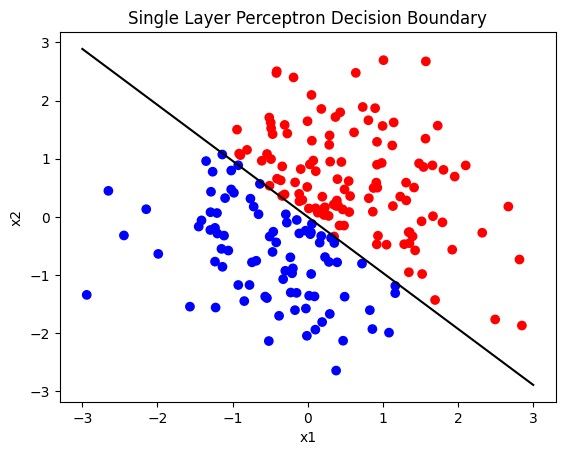

In [2]:
# Generating Synthetic Training Data
X = np.random.randn(200, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, 0)

# Initialize weights and bias
w = np.zeros(2)
b = 0
lr = 0.1

# Train with Perceptron Learning Rule
epochs = 20
for _ in range(epochs):
    for i in range(len(X)):
        z = np.dot(w, X[i]) + b
        y_pred = 1 if z >= 0 else 0
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

# Visualize Decision Boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
# Plot decision boundary
x1 = np.linspace(-3, 3, 100)
x2 = -(w[0] * x1 + b) / w[1]
plt.plot(x1, x2, 'k')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Single Layer Perceptron Decision Boundary")
plt.show()

## Task 2: Multilayer Perseptron    
Objective: Build an MLP classifier using NumPy (from scratch) to learn non-linear decision
boundaries.


### Activation Function Classes

In [3]:
class ReLU:
    # Forward propagation for ReLU activation
    def forward(self, Z):
        self.Z = Z
        return np.maximum(0, Z)

    # Backward propagation for ReLU activation
    # dA is the gradient of loss with respect to the output of ReLU
    def backward(self, dA):
        # Gradient of ReLU:
        # Multiply with incoming gradient (chain rule)
        return dA * (self.Z > 0)

class Sigmoid:
    # Forward propagation for Sigmoid activation
    def forward(self, Z):
        self.A = 1 / (1 + np.exp(-Z))
        return self.A

    # Backward propagation for Sigmoid activation
    # dA is the gradient of loss with respect to the output of Sigmoid
    def backward(self, dA):
        # Derivative of sigmoid function:
        # sigmoid(Z) * (1 - sigmoid(Z))
        # Multiply with incoming gradient (chain rule)
        return dA * self.A * (1 - self.A)

### Loss Function Classes

In [4]:
class BinaryCrossEntropy:
    # Forward pass to compute Binary Cross Entropy loss
    def forward(self, y_pred, y_true):
        # Clip predicted values to avoid log(0) which leads to inf
        self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        self.y_true = y_true
        
        # Binary Cross Entropy loss formula:
        # L = -[y * log(y_pred) + (1 - y) * log(1 - y_pred)]
        # Computed for each training sample
        return -(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred))

    # Backward pass to compute gradient of loss w.r.t predictions
    def backward(self):
        # Gradient of Binary Cross Entropy loss with respect to y_pred
        # This gradient will be passed to the output layer during backpropagation
        # Division by len(self.y_true) ensures averaging over all samples
        return (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred) * len(self.y_true))

### Layer Classes

In [5]:
class Dense:
    def __init__(self, n_input, n_output, activation):
        # Initialize weights with small random values
        self.W = 0.1 * np.random.randn(n_input, n_output)
        
        # Initialize bias for each neuron to zero
        self.b = np.zeros(n_output)
        
        # Activation function for this layer
        self.activation = activation

    # Forward propagation for the dense layer
    def forward(self, X):
        # Store input for use during backpropagation
        self.X = X
        
        # Linear transformation: Z = XW + b 
        self.Z = X @ self.W + self.b
        
        # Apply activation function
        return self.activation.forward(self.Z)

    # Backward propagation for the dense layer
    # dA: gradient of loss with respect to the output of this layer
    def backward(self, dA, lr):
        # Compute gradient after activation function
        dZ = self.activation.backward(dA)
        
        # Gradient of loss with respect to weights
        dW = self.X.T @ dZ
        
        # Gradient of loss with respect to bias
        db = np.sum(dZ, axis=0)
        
        # Gradient of loss with respect to input (to pass to previous layer)
        dX = dZ @ self.W.T

        # Update weights and biases using gradient descent
        self.W -= lr * dW
        self.b -= lr * db

        return dX

### MLP Class

In [6]:
class MLP:
    def __init__(self, layers, loss):
        self.layers = layers
        self.loss = loss
        self.loss_history = []

    # Forward propagation through the entire network
    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    # Training function using backpropagation
    def train(self, X, y, epochs=1000, lr=0.1, verbose=False):
        for epoch in range(epochs):
            # Forward pass to get predictions
            y_pred = self.forward(X)

            # Compute mean loss for the current epoch
            loss = np.mean(self.loss.forward(y_pred, y))

            self.loss_history.append(loss)

            # Compute gradient of loss with respect to predictions
            grad = self.loss.backward()
            
            # Backward pass through layers in reverse order
            for layer in reversed(self.layers):
                grad = layer.backward(grad, lr)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        
        if verbose:
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

### XOR Dataset

In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([[0], [1], [1], [0]], dtype=float)

### Initializing and Traning the Model

In [8]:
np.random.seed(0)
model = MLP(
    layers=[
        Dense(2, 2, ReLU()),
        Dense(2, 1, Sigmoid())
    ],
    loss=BinaryCrossEntropy()
)

model.train(X_xor, y_xor, epochs=1000, lr=0.1, verbose=True)

Epoch    0 | Loss: 0.6932
Epoch  100 | Loss: 0.6912
Epoch  200 | Loss: 0.6826
Epoch  300 | Loss: 0.6548
Epoch  400 | Loss: 0.5891
Epoch  500 | Loss: 0.5122
Epoch  600 | Loss: 0.4176
Epoch  700 | Loss: 0.3013
Epoch  800 | Loss: 0.2081
Epoch  900 | Loss: 0.1467
Epoch  999 | Loss: 0.1074


### Making Predictions

In [9]:
print("Predictions:")
print((model.forward(X_xor) > 0.5).astype(int).ravel())

Predictions:
[0 1 1 0]


### Decision Boundary

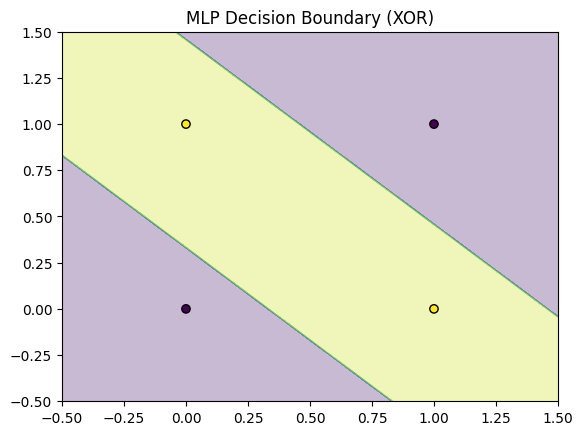

In [10]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.forward(grid)
    Z = (preds > 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolors='k')
    plt.title("MLP Decision Boundary (XOR)")
    plt.show()

plot_decision_boundary(model, X_xor, y_xor)

## Task 3: Perform following tasks 

### 1. Compare single layer vs MLP on linearly separable vs non-linear data (e.g., XOR).

Case 1: Linearly Separable Data

Single Layer Perceptron:
- Successfully classifies linearly separable data.
- Converges quickly using the perceptron learning rule.
- Decision boundary is a straight line.

Multi-Layer Perceptron (MLP):
- Also classifies the data correctly.
- Slightly more computationally expensive due to hidden layers.
- Produces a non-linear decision boundary, though linear separation is sufficient.

Conclusion:
For linearly separable data, both the perceptron and MLP perform well. However, the perceptron is simpler and more efficient.

Case 2: Non-Linearly Separable Data (XOR)

Single Layer Perceptron:
- Fails to correctly classify XOR data.
- Cannot converge to a correct solution.
- Limited to learning only linear decision boundaries.

Multi-Layer Perceptron (MLP):
- Successfully learns the XOR pattern.
- Achieves high accuracy with low loss.
- Hidden layer and non-linear activation enable learning of complex patterns.

Conclusion:
A single-layer perceptron cannot solve non-linear problems such as XOR, whereas an MLP can learn both linear and non-linear decision boundaries.

Summary Table

| Model | Linearly Separable Data | XOR Data |
|------|--------------------------|----------|
| Single Layer Perceptron | Works | Fails |
| Multi-Layer Perceptron | Works | Works |


### 2. Explore how hidden layer size impacts learning.

To study the effect of hidden layer size, the number of neurons in the hidden layer was varied while keeping other parameters constant.

Observations

- 2 Hidden Neurons:  
  So for 2 hidden neurons the mlp was able to learn the decition boundary to seperate the xor data ain about 700 epochs with 0.3 loss with the best looking decition boundary.

- 4 Hidden Neurons:  
  So for 4 hidden neurons the mlp was also able to learn the decition boundary in about 800 epochs with 0.15 loss

- 8 Hidden Neurons:  
  So for 8 hidden neurons the mlp was able to lean in only round about 300 epochs with 0.44 loss at 300 epochs and 0.037 at 1k epochs

Conclusion:  
So the conclusion is that hidden layer size 2 is sufficient to fit xor data.

### 3. Plot loss over training epochs.

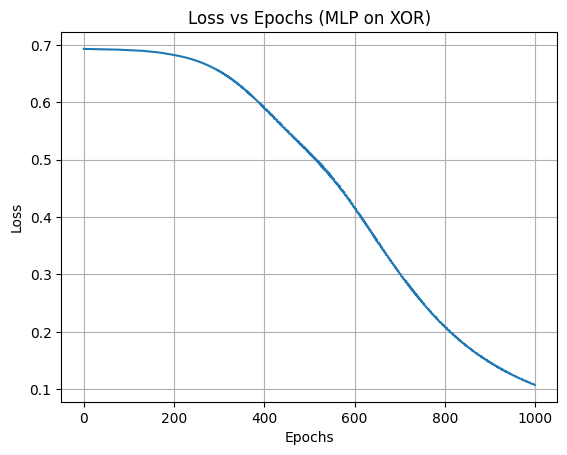

In [11]:
plt.plot(model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (MLP on XOR)")
plt.grid()
plt.show()